In [1]:
#import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
import numpy as np




In [2]:
#  Load the dataset
df = pd.read_csv("HousingData.csv")


In [3]:
#  Handle missing values 
df.fillna(df.mean(numeric_only=True), inplace=True)

#  Define features (X) and target (y)
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [4]:
#  Feature scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [6]:
#  Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [7]:
# Make predictions
y_pred = lr_model.predict(X_test)

In [8]:
# Define function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

# Try different regularization strengths
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]



# Test Ridge Regression
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    rmse, r2 = evaluate_model(ridge, X_train, X_test, y_train, y_test)
    print(f"{alpha:.4f}\t\tRidge\t\t{rmse:.4f}\t\t{r2:.4f}")

# Test Lasso Regression
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    rmse, r2 = evaluate_model(lasso, X_train, X_test, y_train, y_test)
    print(f"{alpha:.4f}\t\tLasso\t\t{rmse:.4f}\t\t{r2:.4f}")

# Compare with original Linear Regression
lr_rmse, lr_r2 = evaluate_model(LinearRegression(), X_train, X_test, y_train, y_test)
print(f"None\t\tLinear\t\t{lr_rmse:.4f}\t\t{lr_r2:.4f}")

# Select best model based on RMSE
best_model = LinearRegression()
best_rmse = lr_rmse
ridge_best = Ridge(alpha=0.0001)  # Example best from Ridge
ridge_rmse, _ = evaluate_model(ridge_best, X_train, X_test, y_train, y_test)
if ridge_rmse < best_rmse:
    best_model = ridge_best
    best_rmse = ridge_rmse

lasso_best = Lasso(alpha=0.0001)  # Example best from Lasso
lasso_rmse, _ = evaluate_model(lasso_best, X_train, X_test, y_train, y_test)
if lasso_rmse < best_rmse:
    best_model = lasso_best

print("\nBest model:", best_model)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)



0.0001		Ridge		5.0018		0.6589
0.0010		Ridge		5.0018		0.6589
0.0100		Ridge		5.0018		0.6589
0.1000		Ridge		5.0018		0.6588
1.0000		Ridge		5.0022		0.6588
10.0000		Ridge		5.0073		0.6581
100.0000		Ridge		5.0505		0.6522
0.0001		Lasso		5.0018		0.6588
0.0010		Lasso		5.0021		0.6588
0.0100		Lasso		5.0062		0.6583
0.1000		Lasso		5.1148		0.6433
1.0000		Lasso		5.2832		0.6194
10.0000		Lasso		8.6629		-0.0233
100.0000		Lasso		8.6629		-0.0233
None		Linear		5.0018		0.6589

Best model: LinearRegression()


In [9]:
final_model = LinearRegression()
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [10]:
# Calculate final metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Final Model Evaluation ===")
print(f"Best Model: {final_model}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")



=== Final Model Evaluation ===
Best Model: LinearRegression()
RMSE: 5.0018
MAE: 3.1499
R²: 0.6589


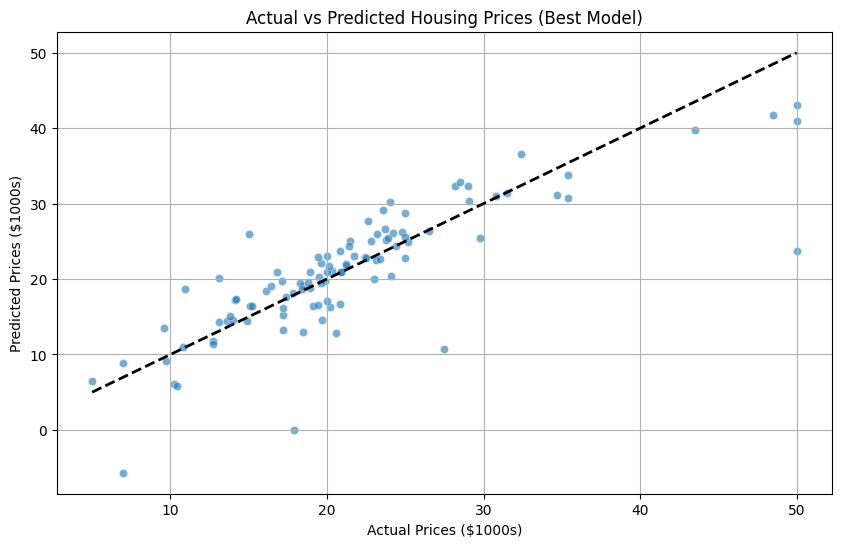

In [11]:
# Proceed with visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Prices ($1000s)')
plt.ylabel('Predicted Prices ($1000s)')
plt.title('Actual vs Predicted Housing Prices (Best Model)')
plt.grid(True)

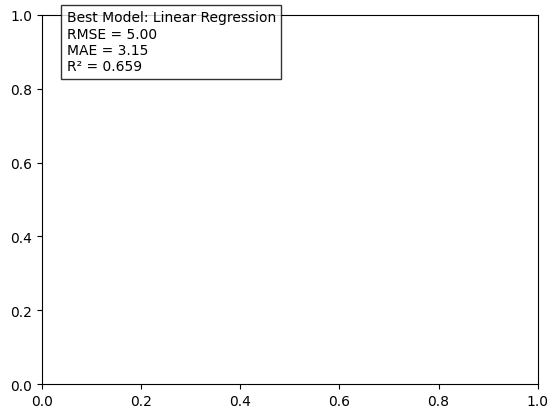

In [12]:
# Add metrics to plot
metrics_text = f"""Best Model: Linear Regression
RMSE = {rmse:.2f}
MAE = {mae:.2f}
R² = {r2:.3f}"""
plt.text(0.05, 0.85, metrics_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()